## Exercise 01
Implement the Ngram- and Jaccard- algorithms from http://textmining.wp.hs-hannover.de/UnscharfeSuche.html

Combining both, what is the similarity of the words:
* "head" and "heat"
* "heat" and "hunt"

**Instructions:**
* Use the symbol `#` for word beginning and `$` for ending.
* Find more word-pairs that are similar in the sense of this algorithm.
* Reduce the number of characters in the word to 2 (bigrams). What are the results now?

In [ ]:
def ngram(string,n):
    liste = []
    if n < len(string):
        for p in range(len(string) - n + 1) :
            tg = string[p:p+n]
            liste.append(tg)
    return liste

def jaccard(A,B):
    schnitt = 0
    for a in A:
        if  a in B:
            schnitt += 1
    vereinigung = len(A) + len(B) - schnitt
    return float(schnitt)/float(vereinigung)

def similarity(w1, w2, n=2):
    pad1, pad2 = f"#{w1}$", f"#{w2}$" 
    ngram1, ngram2 = ngram(pad1, n), ngram(pad2, n)
    return jaccard(ngram1, ngram2)

print("---------- Similarity using n=3 ----------")
print(f"Similarity of \"head\" and \"heat\": {similarity("head", "heat", n=3)}")
print(f"Similarity of \"heat\" and \"hunt\": {similarity("heat", "hunt", n=3)}")

print("\n\n---------- Similarity using n=2 ----------")
print(f"Similarity of \"head\" and \"heat\": {similarity("head", "heat", n=2)}")
print(f"Similarity of \"heat\" and \"hunt\": {similarity("heat", "hunt", n=2)}")

# Short Words don't share a lot of longer n-grams, because there simply aren't so many

---------- Similarity using n=3 ----------
Similarity of "head" and "heat": 0.3333333333333333
Similarity of "heat" and "hunt": 0.0


---------- Similarity using n=2 ----------
Similarity of "head" and "heat": 0.42857142857142855
Similarity of "heat" and "hunt": 0.25


In [10]:
similarity("vorhersehend", "vorhersehen")

0.7857142857142857

## Exercise 02
On the same website from Exercise 01, there is an implementation of a visualization of the Levenshtein table.

* Implement it and apply it for the words "Hallo" and "House".
* Use the visualization to understand the algorithm.
* In the original version, the cost for a substitution is 1. What happens if you increase the substitution cost to 2?

In [16]:
def substitutionsfehler(b1,b2):
    if b1 == b2:
        return 0
    else:
        return 2

def edit_distance(v, w):
    matrix = [[0 for j in range(len(w) + 1)] for i in range(len(v) + 1)]
    for i in range(len(v)+1):
        for j in range(len(w)+1):
            if i > 0 and j > 0:
                val1 = matrix[i-1][j] + 1
                val2 = matrix[i][j-1] + 1
                val3 = matrix[i-1][j-1] + substitutionsfehler(v[i-1],w[j-1]) 
                matrix[i][j] = min(val1, val2, val3)
            elif i > 0:
                matrix[i][j] = matrix[i-1][j] + 1
            elif j > 0:
                matrix[i][j] = matrix[i][j-1] + 1
            else:
                matrix[i][j] = 0 #Die erste Zelle
    return matrix[len(v)][len(w)]

6

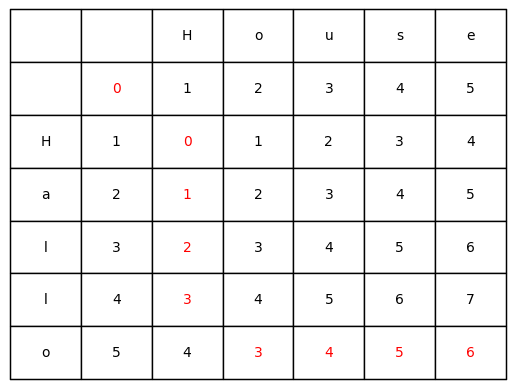

In [17]:
import matplotlib.pylab as pl

def print_lev_table(x,y,tab,backpointer):
    x = ' '+x
    y = '  '+y

    tab.insert(0,list(x))
    for i in range(len(y)):       
        tab[i].insert(0,y[i])
    
    pl.figure()
    tb = pl.table(cellText=tab, loc=(0,0), cellLoc='center')

    tc = tb.get_children()
    for cell in tc: 
        cell.set_height(1/(len(y)))
        cell.set_width(1/(1+len(x)))

    ax = pl.gca()
    ax.set_xticks([])
    ax.set_yticks([])
    
    i,j= len(y)-2,len(x)-1
    while (i,j)  != (0,0):
        tb._cells[i+1,j+1]._text.set_color('red')
        i,j = backpointer[i][j]
    tb._cells[1,1]._text.set_color('red')

def edit_distance_vis(v, w):
    matrix = [[0 for j in range(len(w) + 1)] for i in range(len(v) + 1)]
    backpointer = [[(0,0) for j in range(len(w) + 1)] for i in range(len(v) + 1)]
    for i in range(len(v)+1):
        for j in range(len(w)+1):
            if i > 0 and j > 0:
                val1 = matrix[i-1][j] + 1
                val2 = matrix[i][j-1] + 1
                val3 = matrix[i-1][j-1] + substitutionsfehler(v[i-1],w[j-1]) 
                matrix[i][j] = min(val1, val2, val3)
                if matrix[i][j] == val3:
                    backpointer[i][j] = (i-1,j-1)
                elif matrix[i][j] == val2:
                    backpointer[i][j] = (i,j-1)
                elif matrix[i][j] == val1:
                    backpointer[i][j] = (i-1,j)
            elif i > 0:
                matrix[i][j] = matrix[i-1][j] + 1
                backpointer[i][j] = (i-1,j)
            elif j > 0:
                matrix[i][j] = matrix[i][j-1] + 1
                backpointer[i][j] = (i,j-1)
            else:
                matrix[i][j] = 0 #Die erste Zelle
    print_lev_table(w,v,matrix,backpointer)
    return matrix[len(v)][len(w)]
                       
    
edit_distance_vis('Hallo','House')

With substitution error = 2, the algorithm uses only inserts:

Hallo -> Hllo -> Hlo -> Ho -> Hou -> Hous -> House

## Exercise 03
Using NLTK, compare Porter's stemming with Cistem stemming on English and German words.

* **English words:** `goes`, `wanted`, `housekeeping`
* **German words:** `gehen`, `ging`, `gewünscht`, `haushälterin`

In [19]:
# Make sure you have nltk installed:
# !pip install nltk

import nltk
from nltk.stem import PorterStemmer
from nltk.stem.cistem import Cistem

# Initialize both stemmers
porter = PorterStemmer()
cistem = Cistem(case_insensitive=False)  # case_insensitive is False by default

# Words from the exercise sheet
english_words = ["goes", "wanted", "housekeeping"]
german_words = ["gehen", "ging", "gewünscht", "haushälterin"]

def compare_stemmers(title, words):
    print(f"\n=== {title} ===")
    header = f"{'Original Word':<15} | {'Porter (English)':<18} | {'Cistem (German)':<18}"
    print(header)
    print("-" * len(header))
    for word in words:
        porter_stem = porter.stem(word)
        cistem_stem = cistem.stem(word)
        print(f"{word:<15} | {porter_stem:<18} | {cistem_stem:<18}")

# Compare on both language datasets
compare_stemmers("English Words", english_words)
compare_stemmers("German Words", german_words)


=== English Words ===
Original Word   | Porter (English)   | Cistem (German)   
---------------------------------------------------------
goes            | goe                | goe               
wanted          | want               | wanted            
housekeeping    | housekeep          | housekeeping      

=== German Words ===
Original Word   | Porter (English)   | Cistem (German)   
---------------------------------------------------------
gehen           | gehen              | geh               
ging            | ging               | ging              
gewünscht       | gewünscht          | wunsch            
haushälterin    | haushälterin       | haushalteri       


## Exercise 04
Implement the byte-pair encoding using the article at https://www.aclweb.org/anthology/P16-1162/

Debug and step through the code to see how the algorithm works.